In [60]:
import os
import sys
from dotenv import load_dotenv
from pathlib import Path
import datetime as dt

import pandas as pd
import pandas_datareader.data as pdr
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

In [61]:
sys.path.append("/home/jovyan/notebook")
from Modules.get_market_data import GetMarketData

### 3.2.2 ローソク足チャート

In [62]:
get_market_data = GetMarketData(Path('/home/jovyan/data'))
# 100日前の日付を計算
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=100)

df = get_market_data.get_data_from_yfinance(
    '7616.T',
    start=start_date.strftime('%Y-%m-%d'),
    end=end_date.strftime('%Y-%m-%d')
)

# yfinanceのMultiIndex列をmplfinanceが扱える1階層OHLCVへ整形
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].apply(pd.to_numeric, errors='coerce').dropna()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Date,,,,,
2025-12-23,1710.632711,1725.594513,1709.136531,1716.617432,324700
2025-12-24,1725.594571,1737.564013,1722.602210,1727.589478,407600
2025-12-25,1740.556419,1755.518223,1733.574245,1753.523315,407500
2025-12-26,1760.505493,1768.485121,1757.513133,1760.505493,431600
2025-12-29,1770.479925,1777.462099,1756.515576,1762.999023,453700


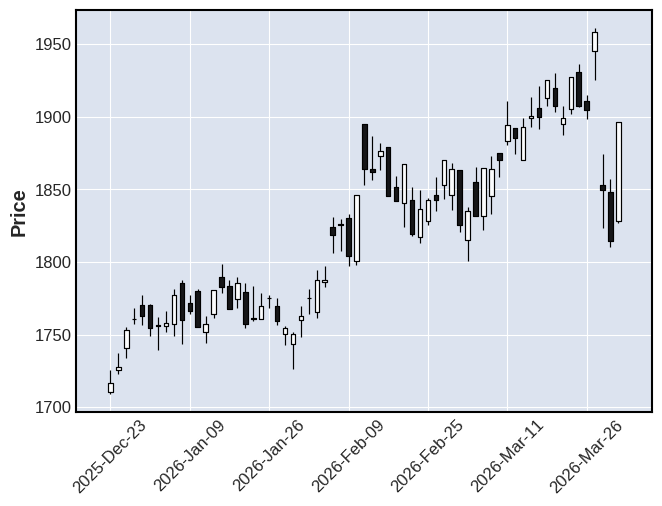

In [63]:
mpf.plot(df, type='candle')

### 3.2.3出来高を表示する

[*********************100%***********************]  1 of 1 completed


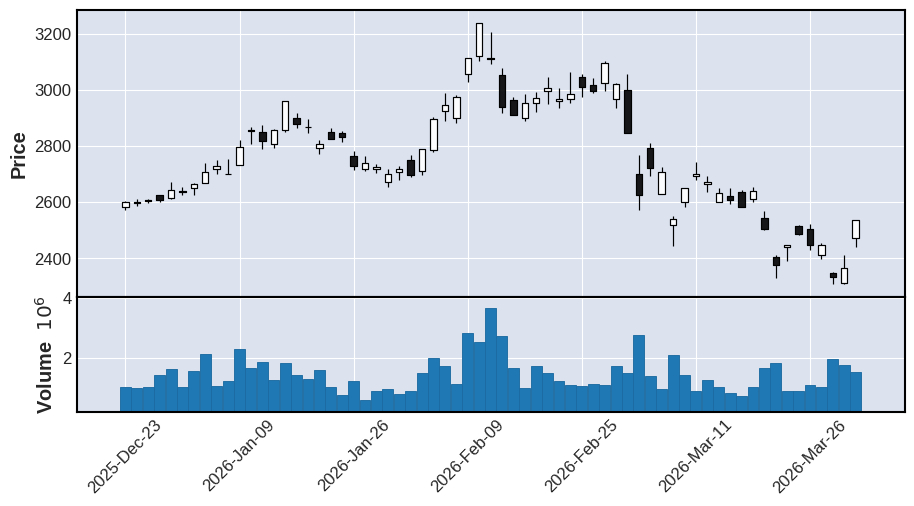

In [64]:
### DMG森精機 (6141.T)
df = get_market_data.get_data_from_yfinance("6141.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
mpf.plot(df, type='candle', figratio=(2, 1), volume=True)

[*********************100%***********************]  1 of 1 completed


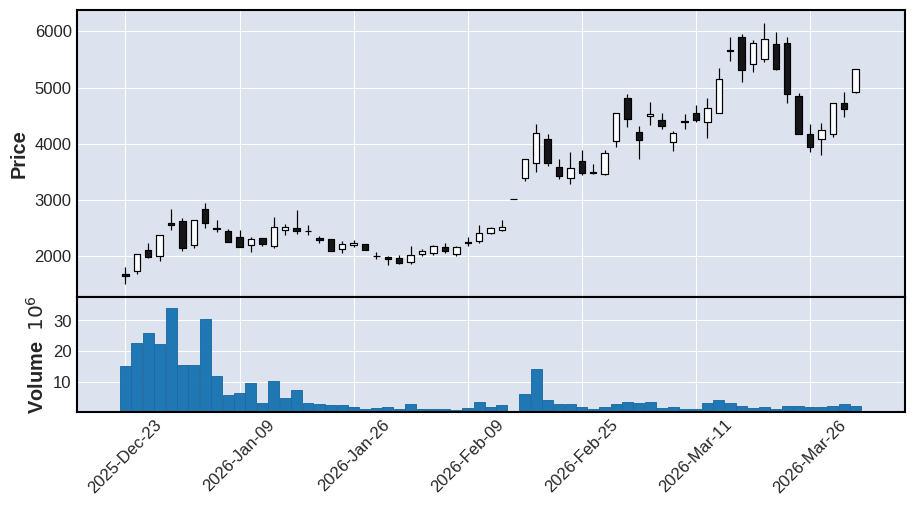

In [65]:
### PowerX (485A.T)
df = get_market_data.get_data_from_yfinance("485A.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
mpf.plot(df, type='candle', figratio=(2, 1), volume=True)

[*********************100%***********************]  1 of 1 completed


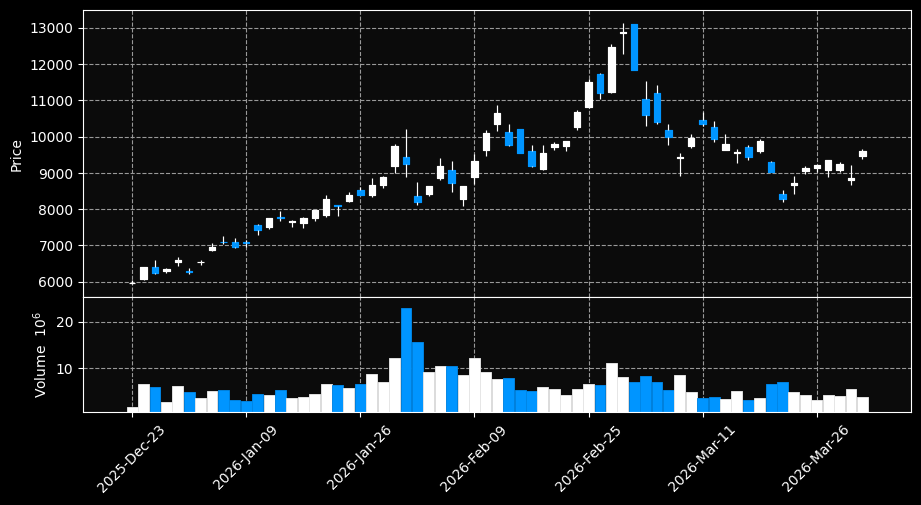

In [66]:
### 住友金属鉱山 (5713.T)
df = get_market_data.get_data_from_yfinance("5713.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
mpf.plot(df, type='candle', figratio=(2, 1), volume=True, style='nightclouds')

### 3.2.7 週足チャート

[*********************100%***********************]  1 of 1 completed


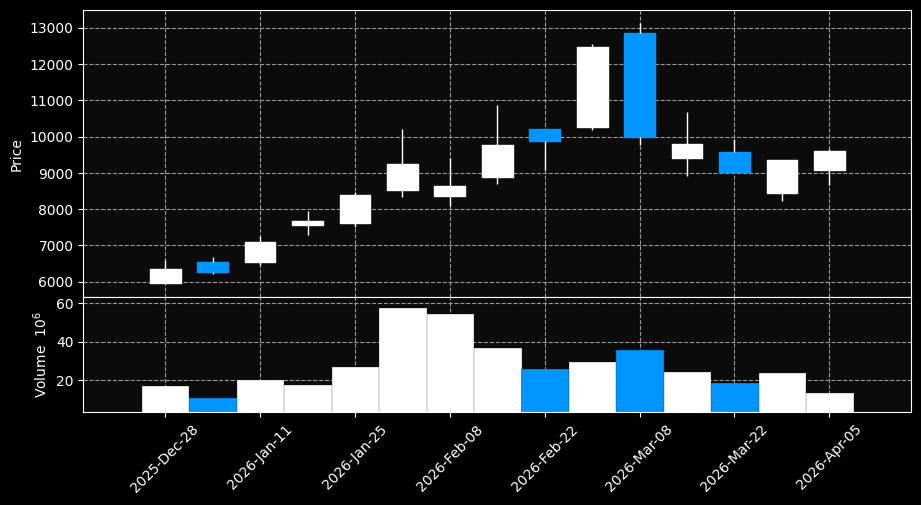

In [67]:
### 住友金属鉱山 (5713.T)
df = get_market_data.get_data_from_yfinance("5713.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
resampled = df.resample('W')
wdf = resampled.aggregate({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'})
mpf.plot(wdf, type='candle', figratio=(2, 1), volume=True, style='nightclouds')


### 3.3.3 移動平均線

[*********************100%***********************]  1 of 1 completed


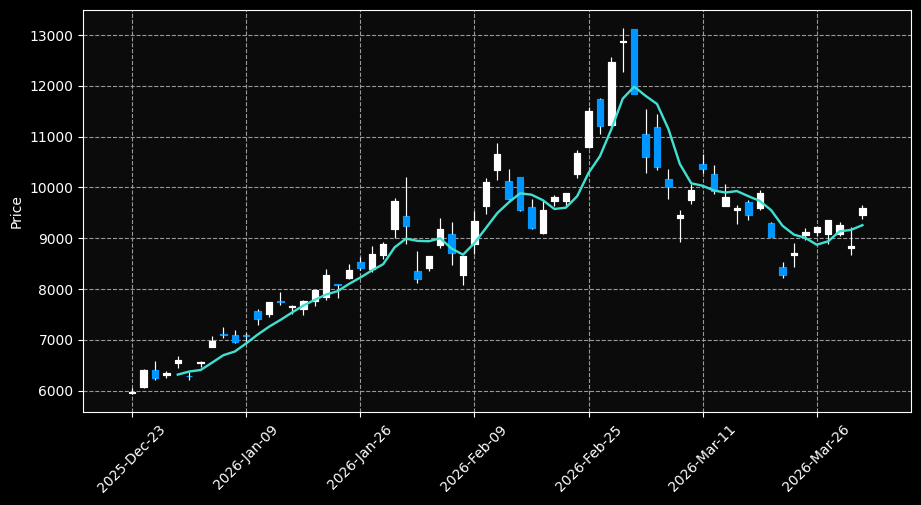

In [68]:
### 住友金属鉱山 (5713.T)
df = get_market_data.get_data_from_yfinance("5713.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
mpf.plot(df, type='candle', mav=(5), figratio=(2, 1), style='nightclouds')

3.3.2 複数の移動平均線を表示する

[*********************100%***********************]  1 of 1 completed


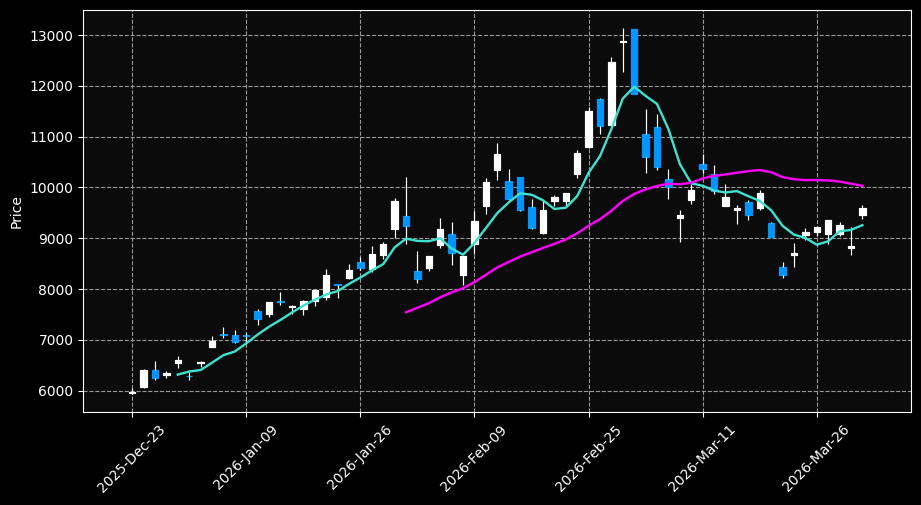

In [69]:
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=100)
### 住友金属鉱山 (5713.T)
df = get_market_data.get_data_from_yfinance("5713.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
mpf.plot(df, type='candle', mav=(5, 25, 75), figratio=(2, 1), style='nightclouds')

[*********************100%***********************]  1 of 1 completed

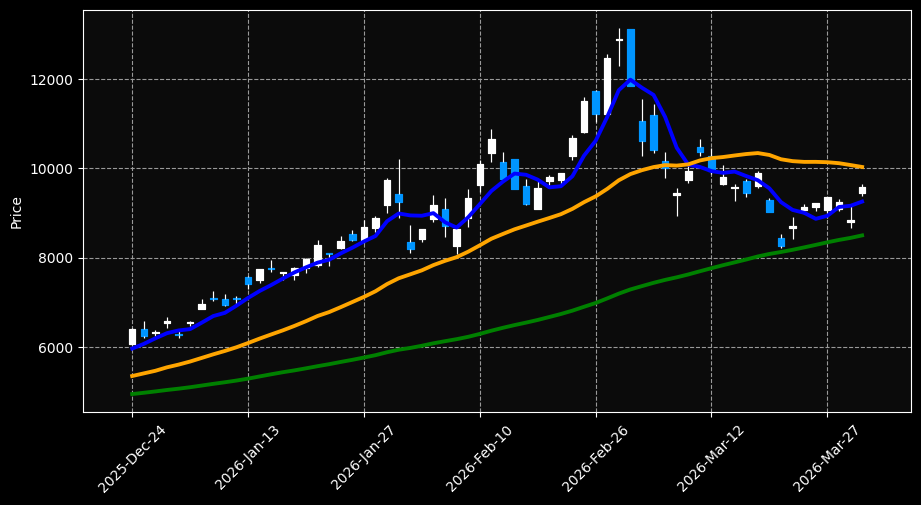

In [ ]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime.now()
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = end_date - dt.timedelta(days=100)

### 住友金属鉱山 (5713.T)
df = get_market_data.get_data_from_yfinance("5713.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()
df["ma75"] = df["Close"].rolling(window=75).mean()

cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma5"], color='blue'),
       mpf.make_addplot(cdf["ma25"], color='orange'),
       mpf.make_addplot(cdf["ma75"], color='green')]
mpf.plot(cdf, type='candle', figratio=(2, 1), addplot=apd, style='nightclouds')

[*********************100%***********************]  1 of 1 completed


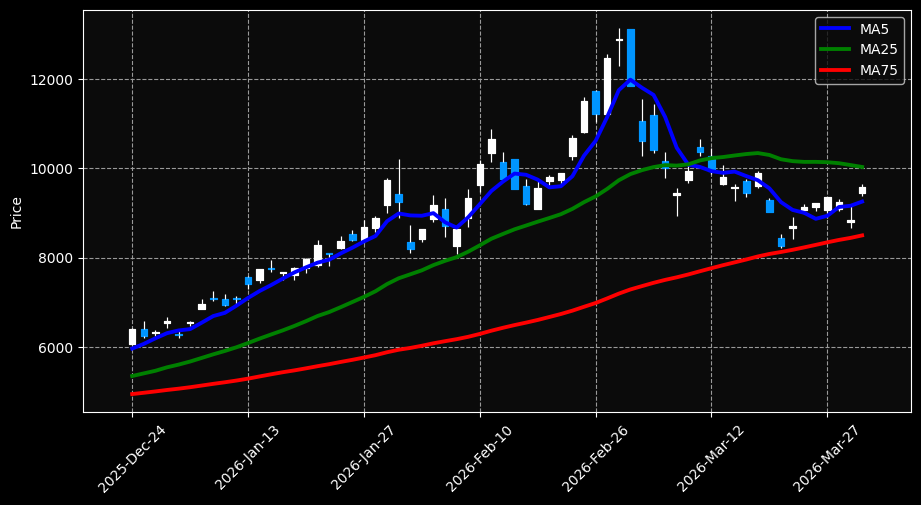

In [89]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime.now()
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = end_date - dt.timedelta(days=100)

### 住友金属鉱山 (5713.T)
df = get_market_data.get_data_from_yfinance("5713.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()
df["ma75"] = df["Close"].rolling(window=75).mean()

cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma5"], color='blue'),
       mpf.make_addplot(cdf["ma25"], color='green'),
       mpf.make_addplot(cdf["ma75"], color='red')]

fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)

l1, l2, l3 = axes[0].lines
axes[0].legend([l1, l2, l3], ['MA5', 'MA25', 'MA75'])
fig.show()

[*********************100%***********************]  1 of 1 completed


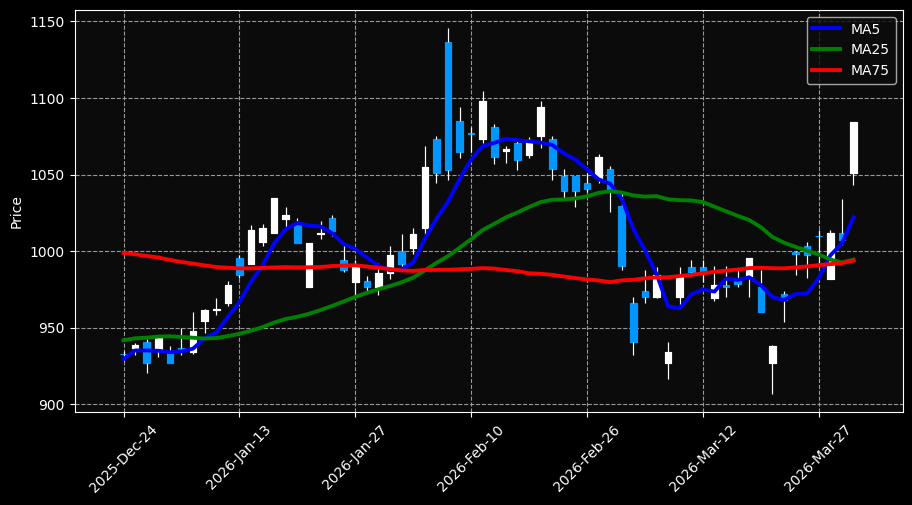

In [96]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime.now()
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = end_date - dt.timedelta(days=100)

### カナビデア (7004.T)
df = get_market_data.get_data_from_yfinance("7004.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()
df["ma75"] = df["Close"].rolling(window=75).mean()

cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma5"], color='blue'),
       mpf.make_addplot(cdf["ma25"], color='green'),
       mpf.make_addplot(cdf["ma75"], color='red')]

fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)

l1, l2, l3 = axes[0].lines
axes[0].legend([l1, l2, l3], ['MA5', 'MA25', 'MA75'])
fig.show()

[*********************100%***********************]  1 of 1 completed


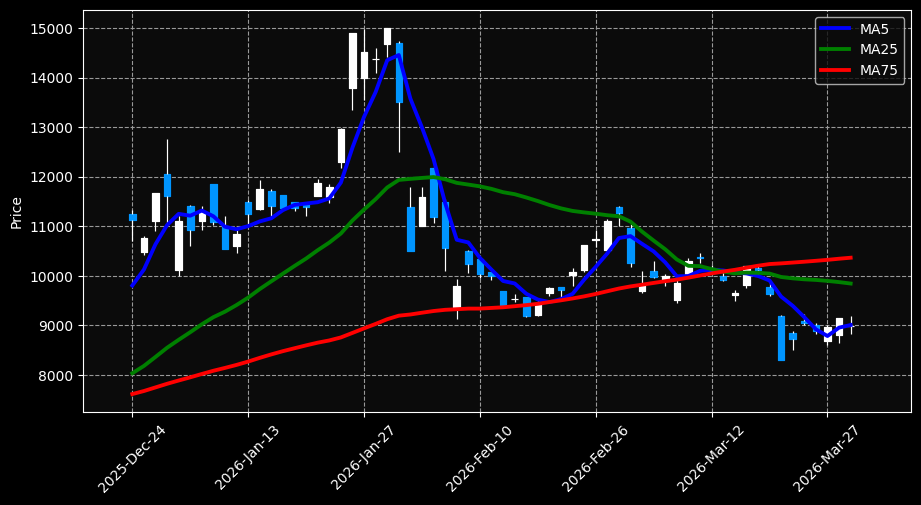

In [97]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime.now()
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = end_date - dt.timedelta(days=100)

### 純プラ信 (1541.T)
df = get_market_data.get_data_from_yfinance("1541.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()
df["ma75"] = df["Close"].rolling(window=75).mean()

cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma5"], color='blue'),
       mpf.make_addplot(cdf["ma25"], color='green'),
       mpf.make_addplot(cdf["ma75"], color='red')]

fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)

l1, l2, l3 = axes[0].lines
axes[0].legend([l1, l2, l3], ['MA5', 'MA25', 'MA75'])
fig.show()

[*********************100%***********************]  1 of 1 completed


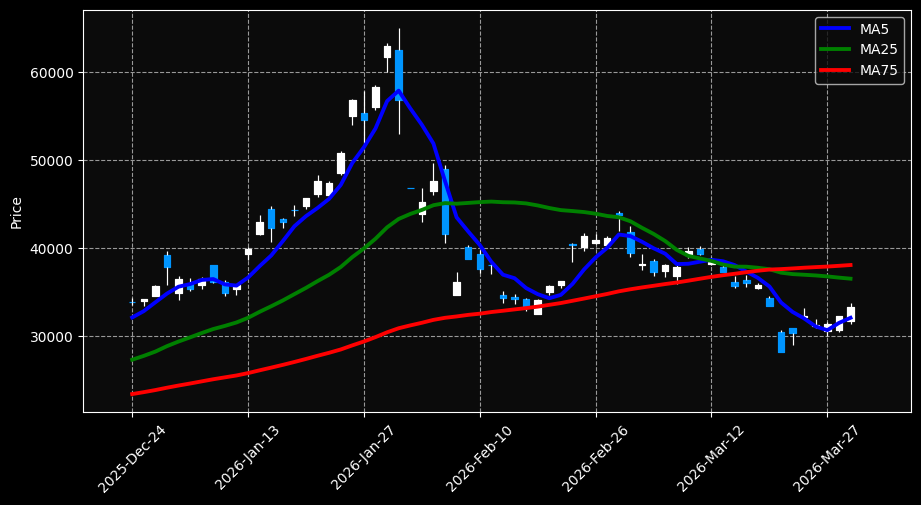

In [98]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime.now()
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = end_date - dt.timedelta(days=100)

### 純銀信託 (1542.T)
df = get_market_data.get_data_from_yfinance("1542.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()
df["ma75"] = df["Close"].rolling(window=75).mean()

cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma5"], color='blue'),
       mpf.make_addplot(cdf["ma25"], color='green'),
       mpf.make_addplot(cdf["ma75"], color='red')]

fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)

l1, l2, l3 = axes[0].lines
axes[0].legend([l1, l2, l3], ['MA5', 'MA25', 'MA75'])
fig.show()

[*********************100%***********************]  1 of 1 completed


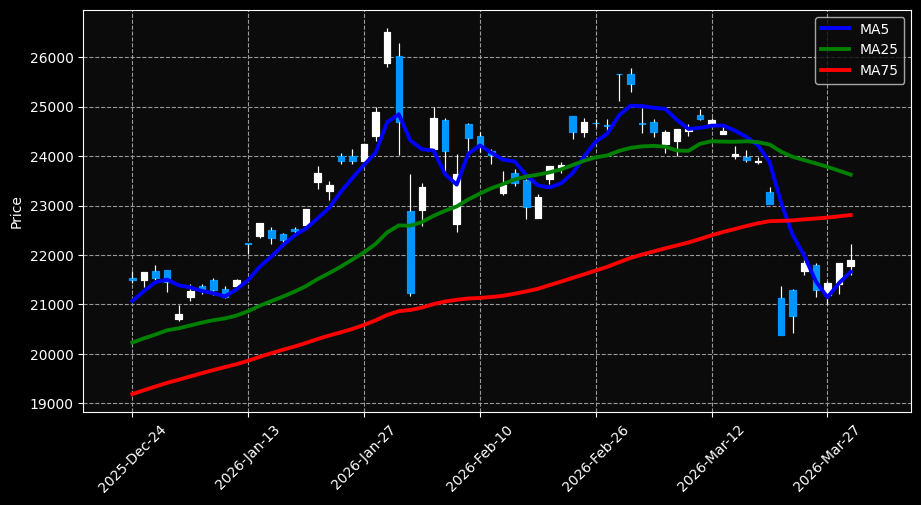

In [100]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime.now()
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = end_date - dt.timedelta(days=100)

### 純金信託 (1540.T)
df = get_market_data.get_data_from_yfinance("1540.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()
df["ma75"] = df["Close"].rolling(window=75).mean()

cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma5"], color='blue'),
       mpf.make_addplot(cdf["ma25"], color='green'),
       mpf.make_addplot(cdf["ma75"], color='red')]

fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)

l1, l2, l3 = axes[0].lines
axes[0].legend([l1, l2, l3], ['MA5', 'MA25', 'MA75'])
fig.show()